# GARCH-M + Black-Litterman 포트폴리오 최적화

**파이프라인 요약**
1. S&P 500 시총 상위 30개 종목 선정
2. 주가 데이터 수집 (2016~2025)
3. GARCH-M 피팅 → Q 행렬 생성
4. Black-Litterman 사후 수익률 계산
5. 포트폴리오 최적화 (MV)
6. Walk-Forward 백테스트

## 0. 라이브러리 설치 및 임포트

In [361]:
# !pip install arch yfinance scipy scikit-learn pandas numpy matplotlib seaborn PyPortfolioOpt

In [362]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from arch import arch_model
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

plt.rcParams['font.family'] = 'AppleGothic'  # Mac
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 분석 기간 설정

In [363]:
START = '2016-01-01'
END   = '2025-12-31'
RF    = 0.05  # 연 무위험수익률

print(f'분석 기간: {START} ~ {END}')
print('유니버스: Wikipedia S&P 500 동적 구성 → 시총 상위 30개 (아래 셀에서 선정)')

분석 기간: 2016-01-01 ~ 2025-12-31
유니버스: Wikipedia S&P 500 동적 구성 → 시총 상위 30개 (아래 셀에서 선정)


In [364]:
import bisect, pickle
from pathlib import Path

CACHE_DIR = Path('data')

# ── S&P 500 멤버십 히스토리 ──────────────────────────────────────────
with open(CACHE_DIR / 'sp500_membership.pkl', 'rb') as f:
    sp500_membership = pickle.load(f)

_membership_dates = sorted(sp500_membership.keys())

def get_sp500_members_at(date):
    ts = pd.Timestamp(date)
    if ts.tz is not None:
        ts = ts.tz_localize(None)
    _dates_naive = [d.tz_localize(None) if (hasattr(d, 'tz') and d.tz is not None) else d
                    for d in _membership_dates]
    idx = bisect.bisect_right(_dates_naive, ts) - 1
    if idx < 0: return set()
    return set(sp500_membership[_membership_dates[idx]])

print(f'멤버십 로드: {len(sp500_membership)}개 월')

# ── 유니버스 목록 ────────────────────────────────────────────────────
universe_df      = pd.read_csv(CACHE_DIR / 'universe.csv')
all_hist_tickers = universe_df['ticker'].tolist()
print(f'역사적 S&P 500 유니버스: {len(all_hist_tickers)}종목')

# ── 전체 가격 데이터 ─────────────────────────────────────────────────
with open(CACHE_DIR / 'prices_full.pkl', 'rb') as f:
    prices_full = pickle.load(f)
print(f'전체 가격 로드: {prices_full.shape}')

# ── 발행주식수 (시계열) → 일별 DataFrame ─────────────────────────────
with open(CACHE_DIR / 'shares_outstanding.pkl', 'rb') as f:
    shares_raw = pickle.load(f)

shares_dict = {}
for ticker, series in shares_raw.items():
    if ticker not in prices_full.columns:
        continue
    s = series.copy()
    if hasattr(s.index, 'tz') and s.index.tz is not None:
        s.index = s.index.tz_localize(None)
    s = s[~s.index.duplicated(keep='last')].sort_index()
    shares_dict[ticker] = s

shares_daily = (pd.DataFrame(shares_dict)
                .reindex(prices_full.index)
                .ffill()
                .bfill())
print(f'발행주식수 로드: {len(shares_dict)}종목')

# ── 일별 시가총액 + 전체 로그수익률 ──────────────────────────────────
mcap_full        = prices_full.multiply(shares_daily)
log_returns_full = np.log(prices_full / prices_full.shift(1)).dropna(how='all')

def get_top_n_at(date, top_n=30, min_history_days=504):
    """IS 마지막 날 기준 S&P 500 시총 상위 top_n 종목 반환"""
    members   = get_sp500_members_at(date)
    available = [t for t in members if t in mcap_full.columns]
    mcap_at   = mcap_full.loc[:date].iloc[-1][available].dropna()
    has_hist  = [t for t in mcap_at.index
                 if log_returns_full[t].loc[:date].dropna().shape[0] >= min_history_days]
    return mcap_at[has_hist].nlargest(top_n).index.tolist()

print(f'\n시가총액: {mcap_full.shape}  |  수익률: {log_returns_full.shape}')


멤버십 로드: 267개 월
역사적 S&P 500 유니버스: 833종목
전체 가격 로드: (2513, 700)
발행주식수 로드: 699종목

시가총액: (2513, 700)  |  수익률: (2512, 700)


In [365]:
# 첫 번째 IS 기간(2년) 종료 시점 기준 → 탐색용 TICKERS 선정
# (섹션 2~5 탐색용. Walk-Forward는 각 IS별로 독립적으로 재선정)
is_days  = 2 * 252
ref_date = log_returns_full.index[is_days - 1]
TICKERS  = get_top_n_at(ref_date, top_n=30)

print(f'탐색 유니버스 ({ref_date.date()} 기준 S&P 500 시총 상위 30개):')
print(TICKERS)


탐색 유니버스 (2018-01-03 기준 S&P 500 시총 상위 30개):
['GE', 'MSFT', 'META', 'BRK-B', 'JPM', 'JNJ', 'XOM', 'BAC', 'V', 'WFC', 'STI', 'AAPL', 'UNH', 'HD', 'PG', 'INTC', 'CVX', 'BA', 'ORCL', 'DIS', 'MA', 'C', 'KO', 'CSCO', 'CMCSA', 'PFE', 'VZ', 'PEP', 'MRK', 'MCD']


In [366]:
# 시가총액 비중 (ref_date 기준)
mcap_at_ref = mcap_full.loc[:ref_date].iloc[-1][TICKERS].dropna()
w_market    = (mcap_at_ref / mcap_at_ref.sum()).reindex(TICKERS).fillna(1 / len(TICKERS))

print('시가총액 비중 (상위 10개):')
print(w_market.sort_values(ascending=False).head(10).apply(lambda x: f'{x:.2%}'))

시가총액 비중 (상위 10개):
GE       10.01%
MSFT      8.61%
META      7.00%
BRK-B     6.96%
JPM       4.27%
JNJ       4.23%
XOM       3.57%
BAC       3.57%
V         3.52%
WFC       3.41%
Name: 2018-01-03 00:00:00, dtype: object


In [367]:
# 로그 수익률 (TICKERS 슬라이스)
log_returns = log_returns_full[TICKERS]

print(f'수익률 데이터: {log_returns.shape}')
print('\n연율화 수익률 (상위 5개):')
annual_ret = log_returns.mean() * 252
print(annual_ret.sort_values(ascending=False).head().apply(lambda x: f'{x:.2%}'))

수익률 데이터: (2512, 30)

연율화 수익률 (상위 5개):
Ticker
AAPL    24.50%
MSFT    23.26%
JPM     18.96%
META    18.87%
MA      18.73%
dtype: object


## 3. GARCH-M 피팅 → Q 행렬 생성

In [368]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import kurtosis as sp_kurtosis

def fit_garch_m(returns_series, ticker=''):
    """
    GARCH-M 피팅 (2-step: GARCH → constrained OLS for λ)
    λ >= 0 제약: 이론상 리스크 프리미엄은 양수여야 함
    """
    r = returns_series.dropna() * 100

    try:
        # Step 1: GARCH(1,1) 피팅
        model = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1)
        res = model.fit(disp='off', show_warning=False)

        h = res.conditional_volatility ** 2
        std_resid = (res.resid / res.conditional_volatility).dropna()

        # Step 2: OLS로 λ 추정 후 λ >= 0 클리핑
        # 이론상 GARCH-M의 λ는 양수 (고변동성 = 고기대수익률)
        # 음수 λ는 단기 노이즈로 처리
        X = np.column_stack([np.ones(len(r)), h.values])
        beta, _, _, _ = np.linalg.lstsq(X, r.values, rcond=None)
        mu      = float(beta[0])
        lambda_ = max(0.0, float(beta[1]))   # 비음수 제약

        # 1-step ahead 분산 예측
        forecast = res.forecast(horizon=1, reindex=False)
        sigma2 = float(forecast.variance.values[-1, 0])

        Q = (mu + lambda_ * sigma2) / 100 * 252
        sigma_annual = np.sqrt(sigma2) / 100 * np.sqrt(252)

        # 진단 지표
        lb_resid = acorr_ljungbox(std_resid, lags=[10], return_df=True)
        lb_arch  = acorr_ljungbox(std_resid ** 2, lags=[10], return_df=True)

        return {
            'Q': Q,
            'mu': mu,
            'lambda_': lambda_,
            'sigma_annual': sigma_annual,
            'sigma2_daily': sigma2,
            'converged': True,
            'aic':       res.aic,
            'bic':       res.bic,
            'loglik':    res.loglikelihood,
            'lb_pval':   float(lb_resid['lb_pvalue'].values[0]),
            'arch_pval': float(lb_arch['lb_pvalue'].values[0]),
            'kurt':      float(sp_kurtosis(std_resid)),
        }

    except Exception as e:
        print(f'  [{ticker}] 피팅 실패: {e}')
        return {'Q': None, 'converged': False}


print('GARCH-M 함수 정의 완료 (λ >= 0 제약 포함)')


GARCH-M 함수 정의 완료 (λ >= 0 제약 포함)


In [369]:
# 전체 기간 GARCH-M 피팅 (섹션 3~5 탐색용)
print('GARCH-M 피팅 중...')
garch_results = {}

for i, ticker in enumerate(TICKERS):
    result = fit_garch_m(log_returns[ticker], ticker=ticker)
    garch_results[ticker] = result
    if result['converged']:
        print(f'  [{i+1:2d}/{len(TICKERS)}] {ticker:6s} | '
              f'Q={result["Q"]:+.4f} | '
              f'λ={result["lambda_"]:+.4f} | '
              f'σ={result["sigma_annual"]:.4f}')

Q_series = pd.Series({
    t: r['Q'] for t, r in garch_results.items() if r['converged']
})
print(f'\n수렴 성공: {Q_series.notna().sum()}/{len(TICKERS)}개')
print(f'Q 범위: {Q_series.min():.4f} ~ {Q_series.max():.4f}')


GARCH-M 피팅 중...
  [ 1/30] GE     | Q=+0.1394 | λ=+0.0000 | σ=0.2693
  [ 2/30] MSFT   | Q=+0.2211 | λ=+0.0027 | σ=0.1696
  [ 3/30] META   | Q=+0.3758 | λ=+0.0000 | σ=0.2665
  [ 4/30] BRK-B  | Q=+0.1878 | λ=+0.0000 | σ=0.1461
  [ 5/30] JPM    | Q=+0.3070 | λ=+0.0000 | σ=0.2067
  [ 6/30] JNJ    | Q=+0.0871 | λ=+0.0223 | σ=0.1609
  [ 7/30] XOM    | Q=+0.0411 | λ=+0.0106 | σ=0.1874
  [ 8/30] BAC    | Q=+0.1910 | λ=+0.0000 | σ=0.2162
  [ 9/30] V      | Q=+0.1531 | λ=+0.0031 | σ=0.1814
  [10/30] WFC    | Q=+0.1313 | λ=+0.0000 | σ=0.2119
  [11/30] STI    | Q=+0.1061 | λ=+0.0000 | σ=1.6764
  [12/30] AAPL   | Q=+0.3295 | λ=+0.0000 | σ=0.1754
  [13/30] UNH    | Q=+0.1621 | λ=+0.0000 | σ=0.2363
  [14/30] HD     | Q=+0.1088 | λ=+0.0068 | σ=0.2066
  [15/30] PG     | Q=+0.0825 | λ=+0.0077 | σ=0.1607
  [16/30] INTC   | Q=+0.1033 | λ=+0.0057 | σ=0.5448
  [17/30] CVX    | Q=+0.0275 | λ=+0.0142 | σ=0.1855
  [18/30] BA     | Q=+0.1314 | λ=+0.0000 | σ=0.2852
  [19/30] ORCL   | Q=+0.2646 | λ=+0.0000 | σ=0.4

=== GARCH-M 진단 지표 ===
  LB p-val  > 0.05 → 잔차 자기상관 없음 (좋음)
  ARCH p-val > 0.05 → ARCH 효과 제거됨  (좋음)
  초과첨도 ≈ 0     → 정규분포에 가까움  (참고용)

              AIC         BIC     LogLik  LB p-val\n(잔차)  ARCH p-val\n(잔차²)      초과첨도
GE     10507.6720  10530.9873 -5249.8360          0.4537             0.1706    3.7451
MSFT    9158.4845   9181.7998 -4575.2422          0.0292             0.9480    3.3256
META   11299.4309  11322.7462 -5645.7154          0.6946             0.9966   24.3456
BRK-B   7444.1321   7467.4474 -3718.0660          0.4109             0.9013    3.3644
JPM     9099.9641   9123.2795 -4545.9821          0.1951             0.9753    5.1068
JNJ     7435.9051   7459.2204 -3713.9525          0.4245             0.9995   10.5130
XOM     9067.2980   9090.6133 -4529.6490          0.9957             0.0298    1.3614
BAC     9867.3508   9890.6661 -4929.6754          0.2910             0.6832    3.4353
V       8542.2838   8565.5992 -4267.1419          0.1502             0.6176    3.7201
WFC   

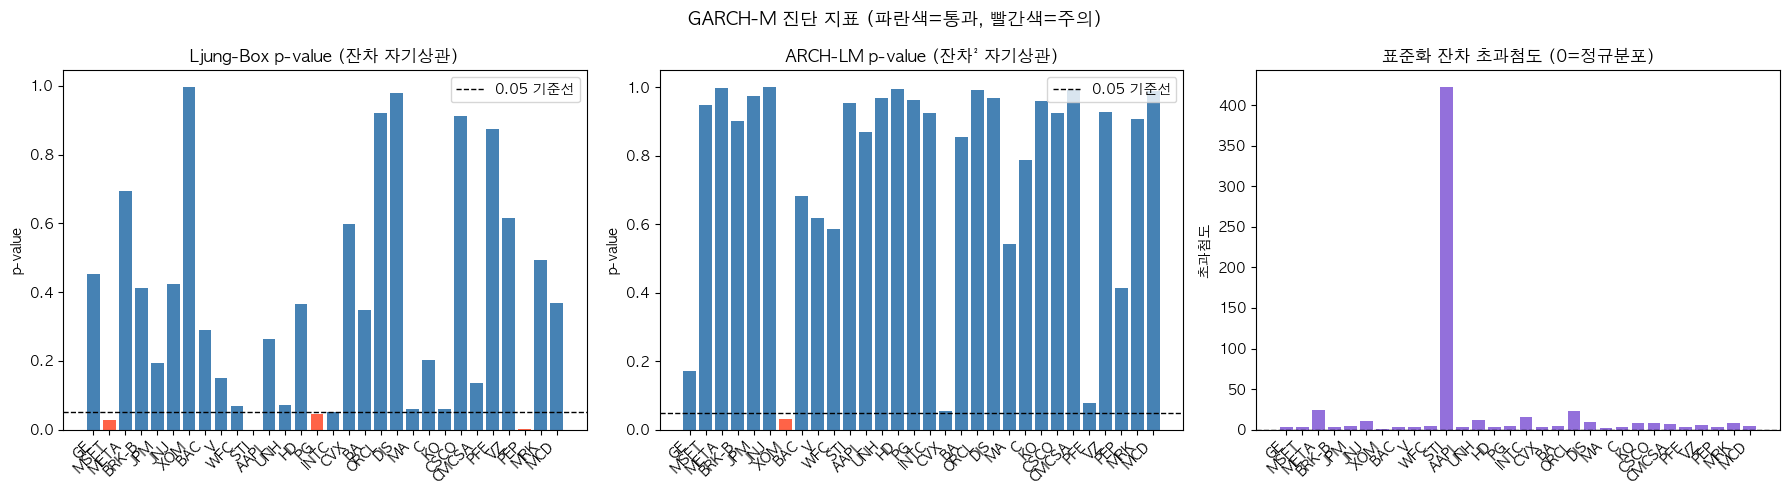

In [370]:
# GARCH-M 진단 지표 요약 테이블
diag_cols = ['aic', 'bic', 'loglik', 'lb_pval', 'arch_pval', 'kurt']
diag_df = pd.DataFrame(
    {t: {k: r[k] for k in diag_cols} for t, r in garch_results.items() if r['converged']}
).T.rename(columns={
    'aic':       'AIC',
    'bic':       'BIC',
    'loglik':    'LogLik',
    'lb_pval':   'LB p-val\n(잔차)',
    'arch_pval': 'ARCH p-val\n(잔차²)',
    'kurt':      '초과첨도'
})

# 판정 기준 안내
print('=== GARCH-M 진단 지표 ===')
print('  LB p-val  > 0.05 → 잔차 자기상관 없음 (좋음)')
print('  ARCH p-val > 0.05 → ARCH 효과 제거됨  (좋음)')
print('  초과첨도 ≈ 0     → 정규분포에 가까움  (참고용)\n')
print(diag_df.round(4).to_string())

# 판정 요약
lb_ok   = (diag_df['LB p-val\n(잔차)']   > 0.05).sum()
arch_ok = (diag_df['ARCH p-val\n(잔차²)'] > 0.05).sum()
n = len(diag_df)
print(f'\nLB   통과: {lb_ok}/{n}  ({lb_ok/n:.0%})')
print(f'ARCH 통과: {arch_ok}/{n}  ({arch_ok/n:.0%})')

# ── 시각화 ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) LB p-value (잔차 자기상관)
colors_lb = ['steelblue' if v > 0.05 else 'tomato'
             for v in diag_df['LB p-val\n(잔차)']]
axes[0].bar(diag_df.index, diag_df['LB p-val\n(잔차)'], color=colors_lb)
axes[0].axhline(0.05, color='black', linestyle='--', linewidth=1, label='0.05 기준선')
axes[0].set_title('Ljung-Box p-value (잔차 자기상관)')
axes[0].set_ylabel('p-value')
axes[0].set_xticklabels(diag_df.index, rotation=45, ha='right')
axes[0].legend()

# 2) ARCH-LM p-value (잔차² 자기상관)
colors_arch = ['steelblue' if v > 0.05 else 'tomato'
               for v in diag_df['ARCH p-val\n(잔차²)']]
axes[1].bar(diag_df.index, diag_df['ARCH p-val\n(잔차²)'], color=colors_arch)
axes[1].axhline(0.05, color='black', linestyle='--', linewidth=1, label='0.05 기준선')
axes[1].set_title('ARCH-LM p-value (잔차² 자기상관)')
axes[1].set_ylabel('p-value')
axes[1].set_xticklabels(diag_df.index, rotation=45, ha='right')
axes[1].legend()

# 3) 초과 첨도
axes[2].bar(diag_df.index, diag_df['초과첨도'], color='mediumpurple')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('표준화 잔차 초과첨도 (0=정규분포)')
axes[2].set_ylabel('초과첨도')
axes[2].set_xticklabels(diag_df.index, rotation=45, ha='right')

plt.suptitle('GARCH-M 진단 지표 (파란색=통과, 빨간색=주의)', fontsize=13)
plt.tight_layout()
plt.show()

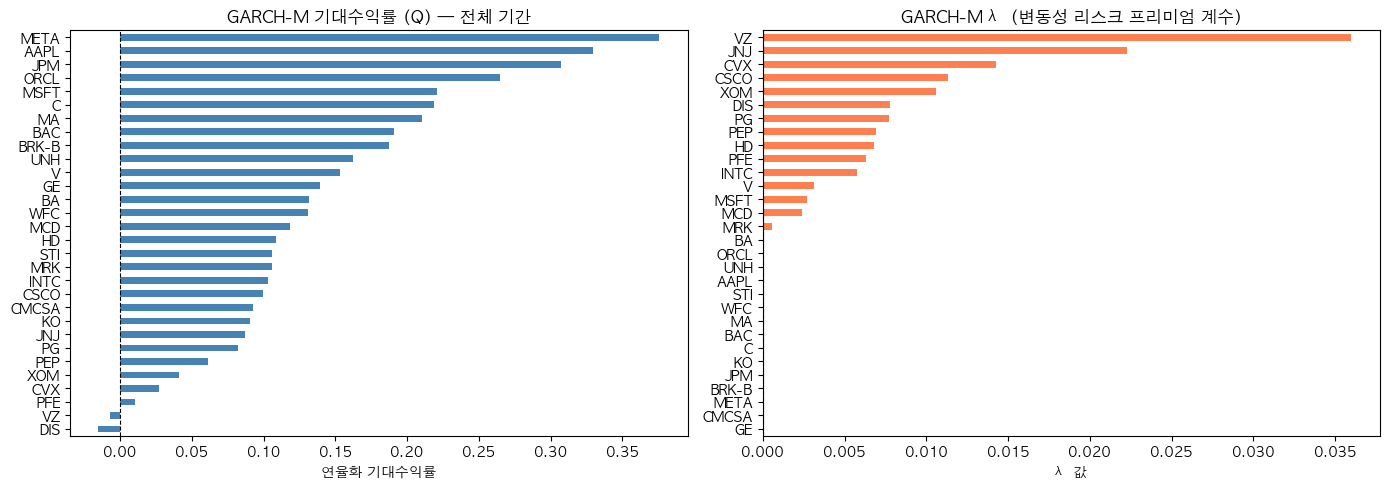

In [371]:
# GARCH-M 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q 분포
Q_series.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('GARCH-M 기대수익률 (Q) — 전체 기간')
axes[0].set_xlabel('연율화 기대수익률')

# λ 분포
lambda_series = pd.Series({
    t: r['lambda_'] for t, r in garch_results.items() if r['converged']
})
lambda_series.sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('GARCH-M λ (변동성 리스크 프리미엄 계수)')
axes[1].set_xlabel('λ 값')

plt.tight_layout()
plt.show()

## 4. Black-Litterman 사후 수익률 계산

In [372]:
def compute_bl_posterior(
    returns_IS,
    w_market,
    Q_vector,
    garch_fits=None,
    tau=None,
    lambda_bl=2.5,
    view_mode='absolute',   # 'absolute' | 'relative' | 'combined'
    rel_top_k=5
):
    """
    Black-Litterman 사후 수익률 계산

    view_mode:
      'absolute' : P = I, Q = GARCH-M 개별 기대수익률
                   "AAPL은 연 29.8%를 낼 것이다"
      'relative' : P = top-k vs bot-k 쌍별 롱숏 (rel_top_k개 뷰)
                   "AMD가 CVX보다 53%p 더 벌 것이다"
                   → 뷰 없는 중간 종목은 Π 방향으로 수렴
      'combined' : 절대뷰 + 상대뷰 동시 사용
    """
    tickers = returns_IS.columns.tolist()
    n = len(tickers)
    T = len(returns_IS)

    if tau is None:
        tau = 1 / T

    # ── 공분산 행렬 (CCC-GARCH) ───────────────────────────────────────
    lw_cov = LedoitWolf().fit(returns_IS).covariance_ * 252
    lw_std = np.sqrt(np.diag(lw_cov))
    R = lw_cov / np.outer(lw_std, lw_std)

    sigma = np.array([
        garch_fits[t]['sigma_annual'] if (garch_fits and t in garch_fits and garch_fits[t].get('converged'))
        else lw_std[i]
        for i, t in enumerate(tickers)
    ])
    cov = np.diag(sigma) @ R @ np.diag(sigma)
    # ─────────────────────────────────────────────────────────────────

    # 시장 균형 수익률 Π
    w  = w_market.reindex(tickers).fillna(1/n).values
    PI = lambda_bl * cov @ w

    Q_series = Q_vector.reindex(tickers)

    # ── 뷰 행렬 구성 ─────────────────────────────────────────────────
    Q_sorted    = Q_series.sort_values(ascending=False)
    top_tickers = Q_sorted.index[:rel_top_k].tolist()
    bot_tickers = Q_sorted.index[-rel_top_k:].tolist()

    # 절대뷰
    P_abs  = np.eye(n)
    Q_abs  = Q_series.values

    # 상대뷰: top_i vs bot_i 쌍별 (rel_top_k개 행)
    P_rel  = np.zeros((rel_top_k, n))
    Q_rel  = np.zeros(rel_top_k)
    for i in range(rel_top_k):
        P_rel[i, tickers.index(top_tickers[i])] = +1
        P_rel[i, tickers.index(bot_tickers[i])] = -1
        Q_rel[i] = Q_sorted.iloc[i] - Q_sorted.iloc[-(i+1)]

    if view_mode == 'absolute':
        P, Q_views = P_abs, Q_abs
    elif view_mode == 'relative':
        P, Q_views = P_rel, Q_rel
    else:  # combined
        P       = np.vstack([P_abs, P_rel])
        Q_views = np.concatenate([Q_abs, Q_rel])
    # ─────────────────────────────────────────────────────────────────

    # Ω: He-Litterman 비례
    Omega = np.diag(np.diag(P @ (tau * cov) @ P.T))

    # BL 공식
    tau_cov_inv = np.linalg.inv(tau * cov)
    P_Omega_inv = P.T @ np.linalg.inv(Omega) @ P

    M_inv  = np.linalg.inv(tau_cov_inv + P_Omega_inv)
    mu_bl  = M_inv @ (tau_cov_inv @ PI + P.T @ np.linalg.inv(Omega) @ Q_views)
    cov_bl = cov + M_inv

    return mu_bl, cov_bl, PI


print('BL 함수 정의 완료 (view_mode: absolute / relative / combined)')


BL 함수 정의 완료 (view_mode: absolute / relative / combined)


상대뷰 구성:
  뷰1: META  (+1) vs XOM   (-1) | Q_diff=0.3909
  뷰2: AAPL  (+1) vs CVX   (-1) | Q_diff=0.3364
  뷰3: JPM   (+1) vs PFE   (-1) | Q_diff=0.2964
  뷰4: ORCL  (+1) vs VZ    (-1) | Q_diff=0.2371
  뷰5: MSFT  (+1) vs DIS   (-1) | Q_diff=0.1800

수익률 비교 (연율화):
      Π (시장균형) Q (GARCH-M) μ_BL 절대뷰 μ_BL 상대뷰
GE      0.0634      0.1394   0.1553   0.0815
MSFT    0.0407      0.2211   0.1808   0.1388
META    0.0524      0.3758   0.2651   0.2201
BRK-B   0.0383      0.1878   0.1349   0.0482
JPM     0.0546      0.3070   0.1912   0.0999
JNJ     0.0256      0.0871   0.0764   0.0088
XOM     0.0370      0.0411   0.0629  -0.0428
BAC     0.0561      0.1910   0.1793   0.0862
V       0.0455      0.1531   0.1688   0.0874
WFC     0.0514      0.1313   0.1507   0.0729
STI     0.2559      0.1061   0.2112   0.3215
AAPL    0.0397      0.3295   0.2069   0.1511
UNH     0.0388      0.1621   0.1378   0.0437
HD      0.0451      0.1088   0.1357   0.0857
PG      0.0251      0.0825   0.0782   0.0330
INTC    0.1125      0.

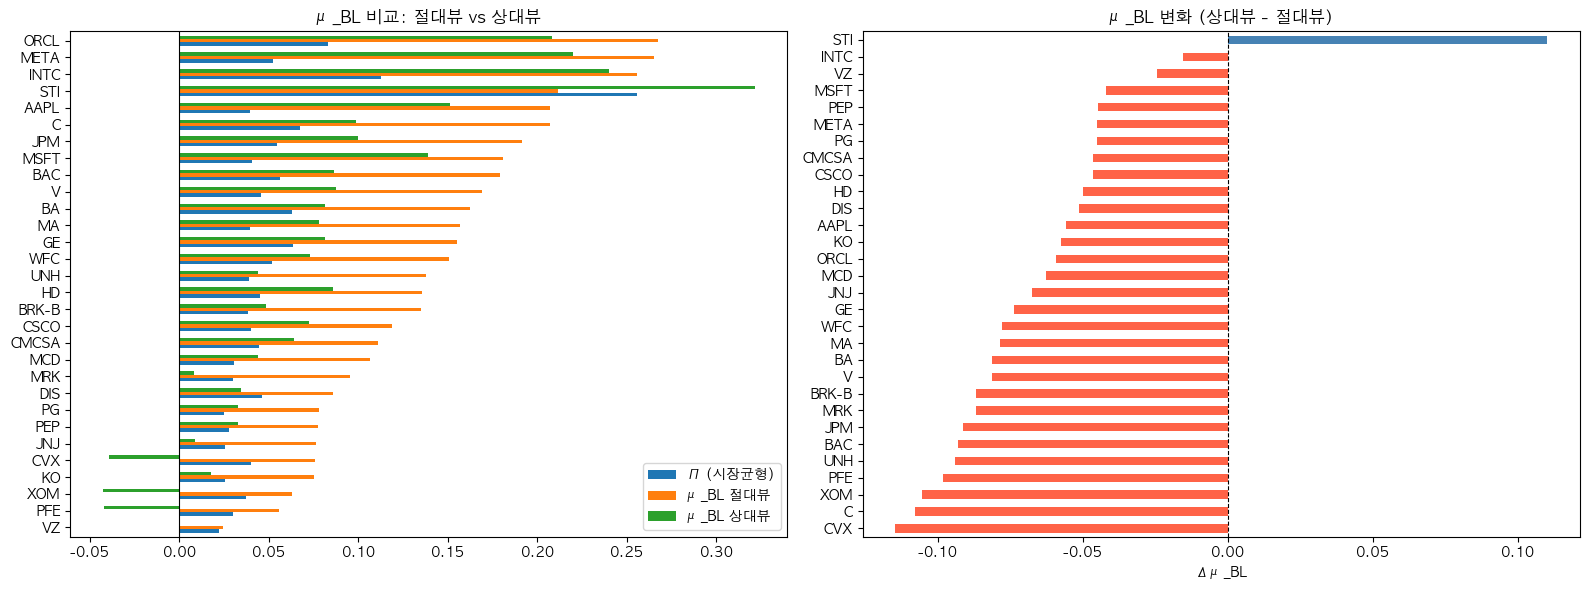

In [373]:
# 절대뷰 vs 상대뷰 μ_BL 비교
mu_abs, _, PI = compute_bl_posterior(
    log_returns, w_market, Q_series,
    garch_fits=garch_results, view_mode='absolute'
)
mu_rel, cov_bl, _ = compute_bl_posterior(
    log_returns, w_market, Q_series,
    garch_fits=garch_results, view_mode='relative', rel_top_k=5
)

Q_sorted    = Q_series.sort_values(ascending=False)
top_tickers = Q_sorted.index[:5].tolist()
bot_tickers = Q_sorted.index[-5:].tolist()

print('상대뷰 구성:')
for i in range(5):
    print(f'  뷰{i+1}: {top_tickers[i]:6s}(+1) vs {bot_tickers[i]:6s}(-1) | Q_diff={Q_sorted.iloc[i]-Q_sorted.iloc[-(i+1)]:.4f}')

comparison = pd.DataFrame({
    'Π (시장균형)':   PI,
    'Q (GARCH-M)':   Q_series.reindex(TICKERS).values,
    'μ_BL 절대뷰':   mu_abs,
    'μ_BL 상대뷰':   mu_rel,
}, index=TICKERS)

print('\n수익률 비교 (연율화):')
print(comparison.applymap(lambda x: f'{x:.4f}'))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

comparison[['Π (시장균형)', 'μ_BL 절대뷰', 'μ_BL 상대뷰']].sort_values('μ_BL 절대뷰').plot(
    kind='barh', ax=axes[0], width=0.6
)
axes[0].set_title('μ_BL 비교: 절대뷰 vs 상대뷰')
axes[0].axvline(0, color='black', linewidth=0.8)

diff = pd.Series(mu_rel - mu_abs, index=TICKERS)
colors = ['steelblue' if v >= 0 else 'tomato' for v in diff.sort_values()]
diff.sort_values().plot(kind='barh', ax=axes[1], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('μ_BL 변화 (상대뷰 - 절대뷰)')
axes[1].set_xlabel('Δμ_BL')

plt.tight_layout()
plt.show()


## 5. 포트폴리오 최적화 (Mean-Variance)

In [374]:
def optimize_mv_bl(mu_bl, cov_bl, rf=0.05, allow_short=False,
                   max_weight=1.0, method='sharpe',
                   returns_is=None, alpha=0.95):
    """
    method:
      'sharpe'  : (μ - rf) / σ 최대화
      'sortino' : (μ - rf) / σ_downside 최대화  ← 하방 변동성만 페널티
      'calmar'  : μ / |MDD_IS| 최대화           ← IS MDD 직접 최소화
      'cvar'    : (μ - rf) / CVaR_annual 최대화 ← 꼬리 위험 최소화
    max_weight  : 종목당 최대 비중 (기본 1.0)
    returns_is  : sortino / calmar / cvar 계산용 IS 일별 수익률
    """
    n = len(mu_bl)
    bounds = [(0, max_weight)] * n if not allow_short else [(-0.1, max_weight)] * n
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    w0 = np.ones(n) / n
    rf_daily = rf / 252

    if method == 'sortino' and returns_is is not None:
        ret_arr = returns_is.values
        def obj(w):
            expected_ret   = float(w @ mu_bl)
            port_rets      = ret_arr @ w
            downside       = np.minimum(port_rets - rf_daily, 0.0)
            semi_std_annual = np.sqrt(np.mean(downside ** 2) * 252)
            if semi_std_annual < 1e-8:
                return -expected_ret
            return -(expected_ret - rf) / semi_std_annual

    elif method == 'calmar' and returns_is is not None:
        ret_arr = returns_is.values
        def obj(w):
            expected_ret = float(w @ mu_bl)          # 연율화
            port_rets    = ret_arr @ w
            cum          = np.cumprod(1 + port_rets)
            mdd          = abs(((cum - np.maximum.accumulate(cum)) / np.maximum.accumulate(cum)).min())
            if mdd < 1e-8:
                return -expected_ret
            return -expected_ret / mdd               # Calmar = 연수익률 / |MDD_IS|

    elif method == 'cvar' and returns_is is not None:
        ret_arr = returns_is.values
        def obj(w):
            expected_ret = float(w @ mu_bl)
            port_rets    = ret_arr @ w
            var_cut      = np.percentile(port_rets, (1 - alpha) * 100)
            tail         = port_rets[port_rets <= var_cut]
            cvar_annual  = -tail.mean() * np.sqrt(252) if len(tail) > 0 else 1e-6
            return -(expected_ret - rf) / cvar_annual

    else:  # sharpe (default, or fallback when returns_is is None)
        def obj(w):
            ret = float(w @ mu_bl)
            vol = np.sqrt(float(w @ cov_bl @ w))
            return -(ret - rf) / vol

    result = minimize(obj, w0, method='SLSQP', bounds=bounds,
                      constraints=constraints,
                      options={'ftol': 1e-9, 'maxiter': 1000})
    return result.x if result.success else w0


# 탐색용 최적화 (기존 호환)
mu_bl, cov_bl, _ = compute_bl_posterior(
    log_returns, w_market, Q_series, garch_fits=garch_results, view_mode='absolute'
)
w_opt = optimize_mv_bl(mu_bl, cov_bl, rf=RF)
weights_bl = pd.Series(w_opt, index=TICKERS).sort_values(ascending=False)
print('BL 최적 가중치 (상위 10개):')
print(weights_bl.head(10).apply(lambda x: f'{x:.4f}'))
print('\noptimize_mv_bl 재정의 완료 (sharpe / sortino / calmar / cvar)')

BL 최적 가중치 (상위 10개):
AAPL    0.4485
META    0.2373
JPM     0.2358
MSFT    0.0592
ORCL    0.0110
STI     0.0041
UNH     0.0041
V       0.0000
C       0.0000
HD      0.0000
dtype: object

optimize_mv_bl 재정의 완료 (sharpe / sortino / calmar / cvar)


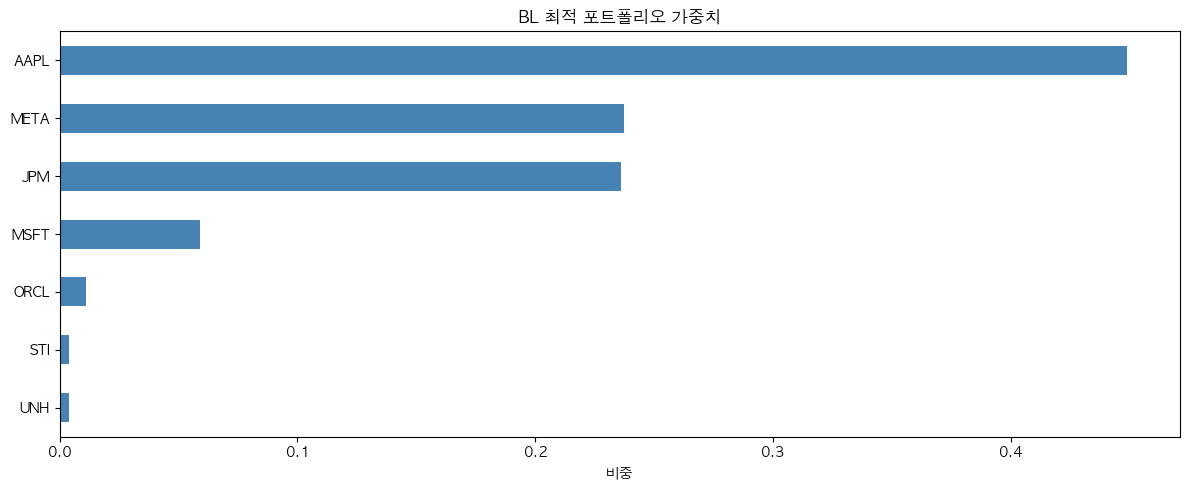

In [375]:
# 가중치 시각화
fig, ax = plt.subplots(figsize=(12, 5))
weights_bl[weights_bl > 0.001].sort_values().plot(
    kind='barh', ax=ax, color='steelblue'
)
ax.set_title('BL 최적 포트폴리오 가중치')
ax.set_xlabel('비중')
plt.tight_layout()
plt.show()

## 6. Walk-Forward 백테스트 (동적 유니버스)

In [376]:
def walk_forward_backtest(is_years=2, oos_months=3, rf=0.05, top_n=30,
                          cost_bps=10, view_mode='absolute',
                          opt_method='sharpe', max_weight=1.0, vol_target=None):
    """
    opt_method : 'sharpe' | 'sortino' | 'calmar' | 'cvar'
    max_weight : 종목당 최대 비중 (기본 1.0)
    vol_target : 변동성 타기팅 목표 연율화 (None=미사용)
    """
    is_days   = is_years * 252
    oos_days  = oos_months * 21
    cost_rate = cost_bps / 10_000
    needs_is  = opt_method in ('cvar', 'sortino', 'calmar')

    all_dates         = log_returns_full.index
    portfolio_returns = []
    benchmark_returns = []
    window_info       = []
    start_idx         = is_days
    w_prev, prev_tickers = None, None

    while start_idx + oos_days <= len(all_dates):
        is_end_date = all_dates[start_idx - 1]
        oos_start   = all_dates[start_idx]
        oos_end     = all_dates[min(start_idx + oos_days - 1, len(all_dates) - 1)]

        window_tickers = get_top_n_at(is_end_date, top_n=top_n, min_history_days=is_days)
        if len(window_tickers) < top_n // 2:
            start_idx += oos_days
            continue

        is_data = (log_returns_full[window_tickers]
                   .iloc[start_idx - is_days : start_idx]
                   .dropna(axis=1, how='any'))
        clean_tickers = is_data.columns.tolist()
        oos_data = log_returns_full[clean_tickers].iloc[start_idx : start_idx + oos_days]

        mcap_at = mcap_full.loc[:is_end_date].iloc[-1][clean_tickers].dropna()
        w_mkt   = (mcap_at / mcap_at.sum()).reindex(clean_tickers).fillna(1 / len(clean_tickers))

        fit_dict = {}
        for ticker in clean_tickers:
            res = fit_garch_m(is_data[ticker], ticker=ticker)
            if res['converged']:
                fit_dict[ticker] = res

        q_dict = {t: r['Q'] for t, r in fit_dict.items()}
        if len(q_dict) < len(clean_tickers) * 0.8:
            start_idx += oos_days
            continue

        try:
            mu_bl, cov_bl, _ = compute_bl_posterior(
                is_data, w_mkt, pd.Series(q_dict),
                garch_fits=fit_dict, view_mode=view_mode
            )
            w_opt = optimize_mv_bl(
                mu_bl, cov_bl, rf=rf,
                method=opt_method,
                max_weight=max_weight,
                returns_is=is_data if needs_is else None
            )
        except Exception:
            start_idx += oos_days
            continue

        # 변동성 타기팅
        if vol_target is not None:
            scale = min(1.0, vol_target / np.sqrt(float(w_opt @ cov_bl @ w_opt)))
        else:
            scale = 1.0

        # 거래비용
        new_w = pd.Series(w_opt, index=clean_tickers)
        if w_prev is not None:
            prev_w   = pd.Series(w_prev, index=prev_tickers)
            all_t    = new_w.index.union(prev_w.index)
            turnover = (new_w.reindex(all_t).fillna(0) -
                        prev_w.reindex(all_t).fillna(0)).abs().sum() / 2
        else:
            turnover = new_w.sum()

        port_ret       = oos_data.values @ w_opt
        port_ret[0]   -= turnover * cost_rate
        port_ret_final = port_ret * scale + (1 - scale) * (rf / 252)

        portfolio_returns.extend(port_ret_final)
        benchmark_returns.extend(oos_data.mean(axis=1).values)
        window_info.append({'oos_start': oos_start, 'oos_end': oos_end,
                            'tickers': clean_tickers, 'turnover': turnover, 'scale': scale})
        w_prev, prev_tickers = w_opt, clean_tickers
        start_idx += oos_days

    idx = log_returns_full.index[is_days : is_days + len(portfolio_returns)]
    return (pd.Series(portfolio_returns, index=idx),
            pd.Series(benchmark_returns, index=idx),
            window_info)


print('Walk-Forward 재정의 완료 (sharpe / sortino / calmar / cvar)')

Walk-Forward 재정의 완료 (sharpe / sortino / calmar / cvar)


▶ 절대뷰 백테스트...
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed

▶ 상대뷰 백테스트...
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed

=== 성과 비교 ===
          연수익률    연변동성   샤프비율      MDD
전략                                    
BL 절대뷰  19.81%  24.03%  0.616  -38.60%
BL 상대뷰  18.91%  27.53% 

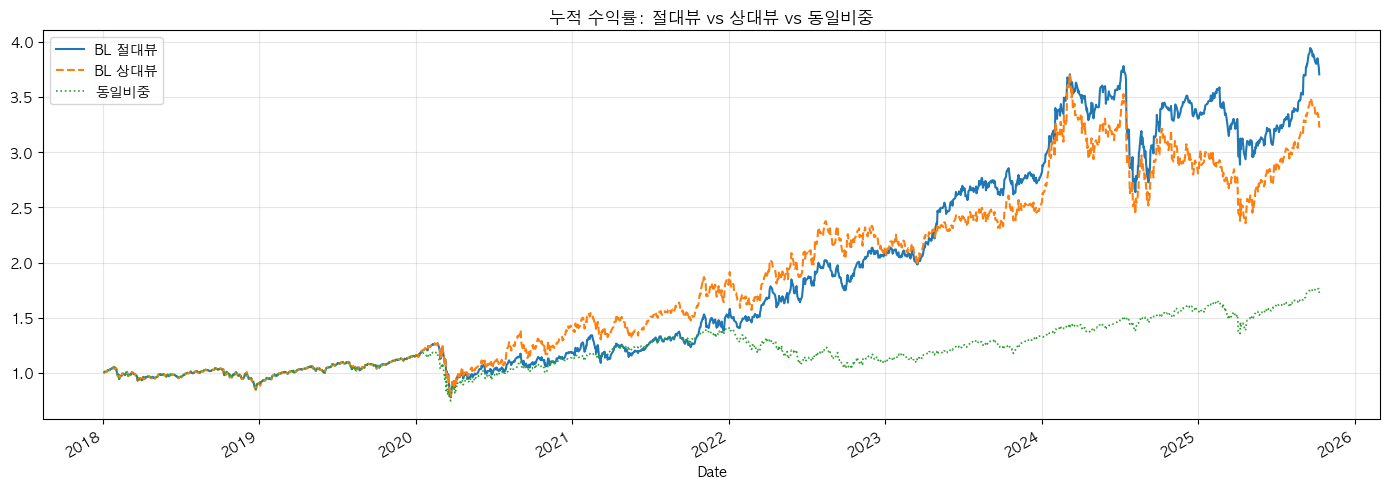

In [377]:
# Walk-Forward: 절대뷰 vs 상대뷰 비교 실행
print('▶ 절대뷰 백테스트...')
port_abs, bench_ret, windows_abs = walk_forward_backtest(
    is_years=2, oos_months=3, rf=RF, top_n=30, cost_bps=10, view_mode='absolute'
)

print('\n▶ 상대뷰 백테스트...')
port_rel, _, windows_rel = walk_forward_backtest(
    is_years=2, oos_months=3, rf=RF, top_n=30, cost_bps=10, view_mode='relative'
)

# 기본 결과는 절대뷰로 세팅 (기존 셀과 호환)
port_ret = port_abs

def compute_metrics(ret, label=''):
    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    sharpe  = (ann_ret - 0.05) / ann_vol
    cum     = (1 + ret).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    return {'전략': label, '연수익률': f'{ann_ret:.2%}',
            '연변동성': f'{ann_vol:.2%}', '샤프비율': f'{sharpe:.3f}', 'MDD': f'{mdd:.2%}'}

metrics = pd.DataFrame([
    compute_metrics(port_abs,  'BL 절대뷰'),
    compute_metrics(port_rel,  'BL 상대뷰'),
    compute_metrics(bench_ret, '동일비중'),
]).set_index('전략')

print('\n=== 성과 비교 ===')
print(metrics.to_string())

# 누적 수익률 비교
fig, ax = plt.subplots(figsize=(14, 5))
(1 + port_abs).cumprod().plot(ax=ax, label='BL 절대뷰', linewidth=1.5)
(1 + port_rel).cumprod().plot(ax=ax, label='BL 상대뷰', linewidth=1.5, linestyle='--')
(1 + bench_ret).cumprod().plot(ax=ax, label='동일비중', linewidth=1.2, linestyle=':')
ax.set_title('누적 수익률: 절대뷰 vs 상대뷰 vs 동일비중')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


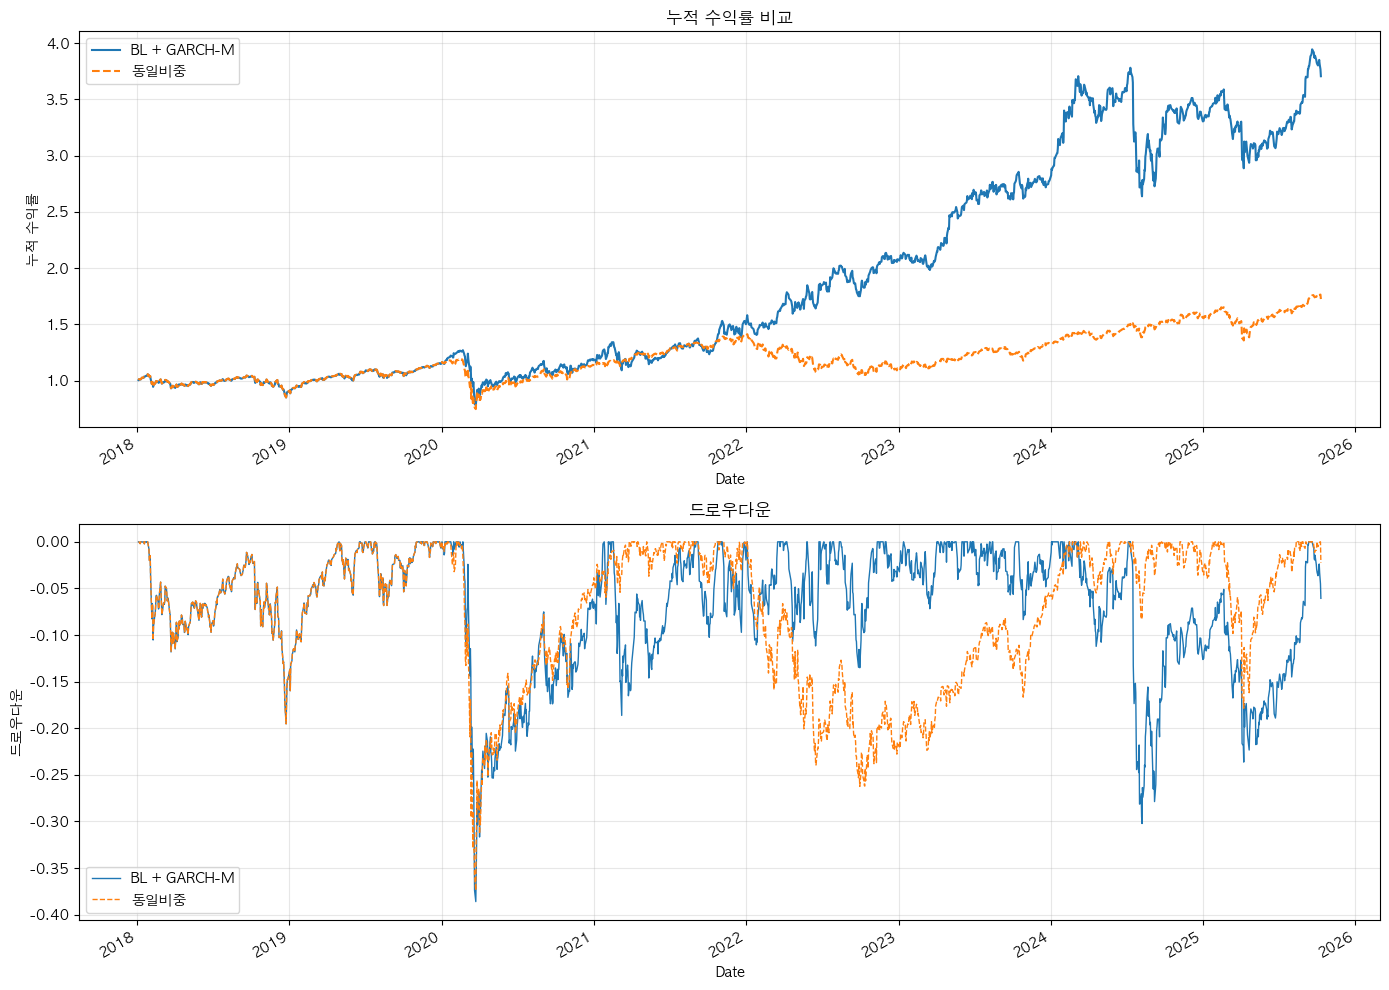

In [378]:
# 누적 수익률 시각화
cum_bl    = (1 + port_ret).cumprod()
cum_bench = (1 + bench_ret).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 누적 수익률
cum_bl.plot(ax=axes[0], label='BL + GARCH-M', linewidth=1.5)
cum_bench.plot(ax=axes[0], label='동일비중', linewidth=1.5, linestyle='--')
axes[0].set_title('누적 수익률 비교')
axes[0].set_ylabel('누적 수익률')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 드로우다운
def calc_drawdown(ret):
    cum = (1 + ret).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

calc_drawdown(port_ret).plot(ax=axes[1], label='BL + GARCH-M', linewidth=1)
calc_drawdown(bench_ret).plot(ax=axes[1], label='동일비중', linewidth=1, linestyle='--')
axes[1].set_title('드로우다운')
axes[1].set_ylabel('드로우다운')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

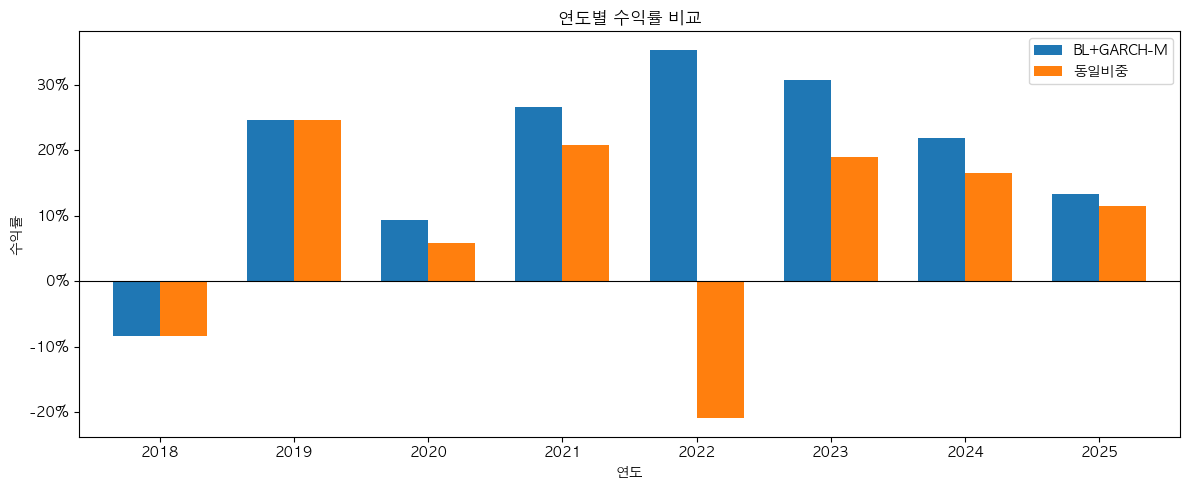

     BL+GARCH-M     동일비중
Date                    
2018     -8.44%   -8.32%
2019     24.62%   24.63%
2020      9.38%    5.88%
2021     26.60%   20.84%
2022     35.36%  -20.96%
2023     30.70%   19.02%
2024     21.93%   16.49%
2025     13.33%   11.48%


In [379]:
# 연도별 수익률 비교
annual_port  = port_ret.resample('Y').sum()
annual_bench = bench_ret.resample('Y').sum()

annual_compare = pd.DataFrame({
    'BL+GARCH-M': annual_port,
    '동일비중': annual_bench
})

annual_compare.index = annual_compare.index.year

fig, ax = plt.subplots(figsize=(12, 5))
annual_compare.plot(kind='bar', ax=ax, width=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('연도별 수익률 비교')
ax.set_ylabel('수익률')
ax.set_xlabel('연도')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(annual_compare.applymap(lambda x: f'{x:.2%}'))

## 7. MDD 개선 전략 비교


▶ ① 기본 Sharpe 백테스트 중...
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  완료 (31 윈도우)

▶ ② 캡 15% 백테스트 중...
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimensions are not allowed
  완료 (31 윈도우)

▶ ③ 캡 15% + VT 15% 백테스트 중...
  [STI] 피팅 실패: negative dimensions are not allowed
  [STI] 피팅 실패: negative dimen

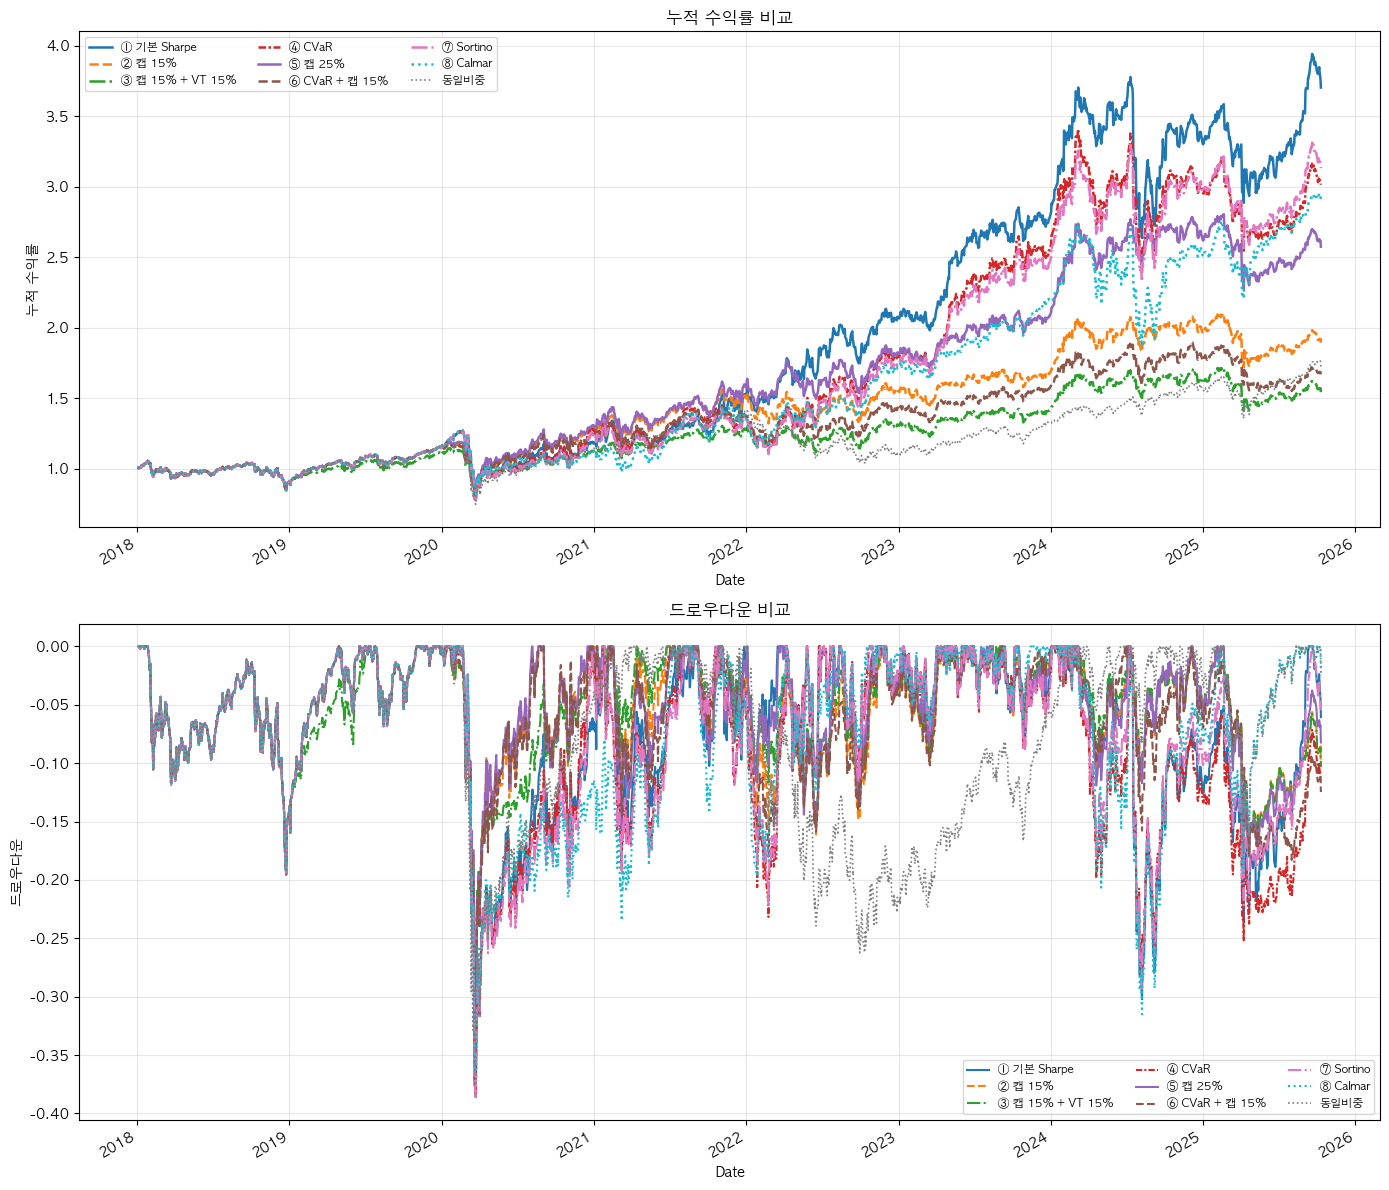

In [380]:
# ── MDD 개선 전략 비교 (8가지) ───────────────────────────────────────
strategies = [
    ('① 기본 Sharpe',       dict(opt_method='sharpe',  max_weight=1.0,  vol_target=None)),
    ('② 캡 15%',            dict(opt_method='sharpe',  max_weight=0.15, vol_target=None)),
    ('③ 캡 15% + VT 15%',   dict(opt_method='sharpe',  max_weight=0.15, vol_target=0.15)),
    ('④ CVaR',              dict(opt_method='cvar',    max_weight=1.0,  vol_target=None)),
    ('⑤ 캡 25%',            dict(opt_method='sharpe',  max_weight=0.25, vol_target=None)),
    ('⑥ CVaR + 캡 15%',     dict(opt_method='cvar',    max_weight=0.15, vol_target=None)),
    ('⑦ Sortino',           dict(opt_method='sortino', max_weight=1.0,  vol_target=None)),
    ('⑧ Calmar',            dict(opt_method='calmar',  max_weight=1.0,  vol_target=None)),
]

results = {}
bench_series = None

for name, kwargs in strategies:
    print(f'\n▶ {name} 백테스트 중...')
    port, bench, info = walk_forward_backtest(
        is_years=2, oos_months=3, rf=RF, top_n=30, cost_bps=10,
        view_mode='absolute', **kwargs
    )
    results[name] = port
    if bench_series is None:
        bench_series = bench
    print(f'  완료 ({len(info)} 윈도우)')

# ── 성과 지표 계산 ─────────────────────────────────────────────────
def compute_metrics_full(ret, label):
    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    sharpe  = (ann_ret - RF) / ann_vol
    cum     = (1 + ret).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar  = ann_ret / abs(mdd)
    return {'전략': label,
            '연수익률': f'{ann_ret:.2%}',
            '연변동성': f'{ann_vol:.2%}',
            '샤프비율': f'{sharpe:.3f}',
            'MDD':     f'{mdd:.2%}',
            'Calmar':  f'{calmar:.3f}'}

rows = [compute_metrics_full(v, k) for k, v in results.items()]
rows.append(compute_metrics_full(bench_series, '동일비중'))
metrics_df = pd.DataFrame(rows).set_index('전략')

print('\n=== MDD 개선 전략 비교 ===')
print(metrics_df.to_string())

# ── 시각화 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
          '#9467bd','#8c564b','#e377c2','#17becf','#7f7f7f']
styles = ['-','--','-.', (0,(3,1,1,1)), '-','--','-.',':',' ']

for (name, ret), color, ls in zip(results.items(), colors, styles):
    (1 + ret).cumprod().plot(ax=axes[0], label=name, color=color,
                              linestyle=ls, linewidth=1.8)
(1 + bench_series).cumprod().plot(ax=axes[0], label='동일비중',
                                   color=colors[8], linestyle=':', linewidth=1.2)
axes[0].set_title('누적 수익률 비교')
axes[0].legend(fontsize=8, ncol=3)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('누적 수익률')

def calc_dd(ret):
    cum = (1 + ret).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

for (name, ret), color, ls in zip(results.items(), colors, styles):
    calc_dd(ret).plot(ax=axes[1], label=name, color=color,
                      linestyle=ls, linewidth=1.5)
calc_dd(bench_series).plot(ax=axes[1], label='동일비중',
                            color=colors[8], linestyle=':', linewidth=1.2)
axes[1].set_title('드로우다운 비교')
axes[1].legend(fontsize=8, ncol=3)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylabel('드로우다운')

plt.tight_layout()
plt.show()